In [1]:
import cv2
import numpy as np
import mediapipe as mp
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Video

print("All libraries are ready!")

All libraries are ready!


In [2]:
import pandas as pd
import numpy as np
from IPython.display import Video
from process_videos.helpers.video_to_dataframe import video_to_dataframe
from process_videos.helpers.data_to_csv import *

In [3]:
Video("data/ahad_data/ahad_swipe_right.mp4", embed=True, width=400)

In [4]:
Video("data/anujaya_data/anu_swipe_left.mp4", embed=True, width=400)

In [5]:
Video("data/shahzaib_data/shahzaib_rotate.mp4", embed=True, width=400)

### E01: Create your own videos, annotate them, and load them here.

In [6]:
def create_and_annotate_dataframe_from_video(
    video_path: str,
    annotation_path: str,
    flip_image: bool = True,
):
    # 1) extract frames
    frames = video_to_dataframe(video_path, flip_image=flip_image)
    frames.index = pd.to_timedelta(frames.index, unit="ms")
    frames.index.name = "time"

    # 2) try to read ELAN with label in col 8, otherwise fall back to col 6
    try:
        annotations = pd.read_csv(
            annotation_path,
            sep="\t",
            header=None,
            usecols=[3, 5, 8],           # start_sec, end_sec, label (type A)
            names=["start", "end", "label"],
        )
    except Exception:
        annotations = pd.read_csv(
            annotation_path,
            sep="\t",
            header=None,
            usecols=[1, 3, 6],           # start_sec, end_sec, label (type B)
            names=["start", "end", "label"],
        )

    annotations["start"] = pd.to_timedelta(annotations["start"], unit="s")
    annotations["end"]   = pd.to_timedelta(annotations["end"],   unit="s")

    # 3) assign ground_truth from annotations
    frames["ground_truth"] = "idle"
    for _, ann in annotations.iterrows():
        mask = (frames.index >= ann["start"]) & (frames.index <= ann["end"])
        frames.loc[mask, "ground_truth"] = ann["label"]

    # 4) normalize labels so formats like "Swipe right " → "swipe_right"
    frames["ground_truth"] = (
        frames["ground_truth"]
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )

    return frames


In [7]:
videos = [
    ("data/ahad_data/ahad_swipe_right.mp4", "data/ahad_data/ahad_swipe_right_annotation.txt", True, "ahad"),
    ("data/anujaya_data/anu_swipe_left.mp4", "data/anujaya_data/anu_swipe_left_annotation.txt", True, "anu"),
    ("data/shahzaib_data/shahzaib_rotate.mp4", "data/shahzaib_data/shahzaib_rotate_annotation.txt", True, "shahzaib"),
]

list_of_frames = []

for video_path, ann_path, flip, person_id in videos:
    df = create_and_annotate_dataframe_from_video(video_path, ann_path, flip_image=flip)

    # normalize labels
    df["ground_truth"] = (
        df["ground_truth"]
        .astype(str)
        .str.strip()          
        .str.lower()          
        .str.replace(" ", "_")  
    )

    # keep person id
    df["person_id"] = person_id

    # dominant gesture label (ignoring idle)
    non_idle = df.loc[df["ground_truth"] != "idle", "ground_truth"]
    df["video_label"] = non_idle.mode().iloc[0] if len(non_idle) else "unknown"

    list_of_frames.append(df)

len(list_of_frames), [df["video_label"].iloc[0] for df in list_of_frames]


I0000 00:00:1772136069.766629   16224 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1772136069.772358   21105 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.1), renderer: Mesa Intel(R) Graphics (ADL GT2)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1772136069.895590   21089 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1772136069.933540   21092 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
/home/anu/PycharmProjects/MLProject/.venv/lib/python3.11/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.Get

(3, ['swipe_right', 'swipe_left', 'rotate'])

In [8]:
combined_df = pd.concat(list_of_frames, ignore_index=False)
combined_df.to_csv("data/csv_results/all_frames_with_ground_truth.csv")

### E02 — Analysis of the data (plots + statistics)

##### Estimating frames per sec

In [9]:
def estimate_fps(frames: pd.DataFrame) -> float:
    if not isinstance(frames.index, pd.TimedeltaIndex) or len(frames) < 3:
        return np.nan
    dt = frames.index.to_series().diff().dropna().dt.total_seconds()
    med = dt.median()
    if med == 0 or pd.isna(med):
        return np.nan
    return 1.0 / med


##### fps + duration + label_distribution

In [28]:
summary = []
for i, df in enumerate(list_of_frames):
    fps = estimate_fps(df)
    duration = df.index.max().total_seconds() if len(df) else 0
    label_counts = df["ground_truth"].value_counts().to_dict()
    summary.append({
        "index": i,
        "person": df["person_id"].iloc[0],
        "video_label": df["video_label"].iloc[0],
        "fps_est": round(fps, 2) if not np.isnan(fps) else np.nan,
        "duration_s": round(duration, 2),
        "counts": label_counts
    })

pd.DataFrame(summary)


,index,person,video_label,fps_est,duration_s,counts
0,0,ahad,swipe_right,30.0,12.67,"{'idle': 254, 'swipe_right': 127}"
1,1,anu,swipe_left,30.0,14.21,"{'swipe_left': 220, 'idle': 207}"
2,2,shahzaib,rotate,30.0,11.90,"{'rotate': 265, 'idle': 93}"


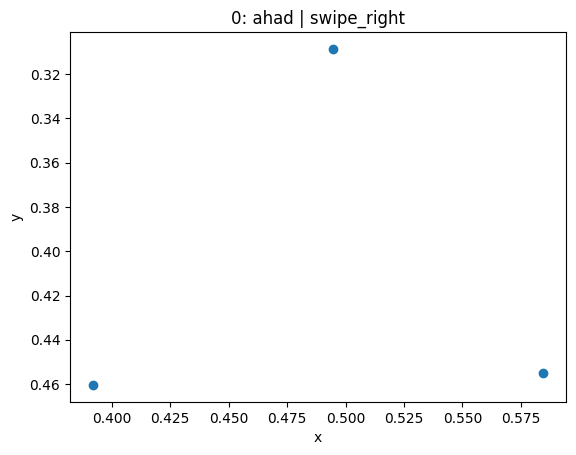

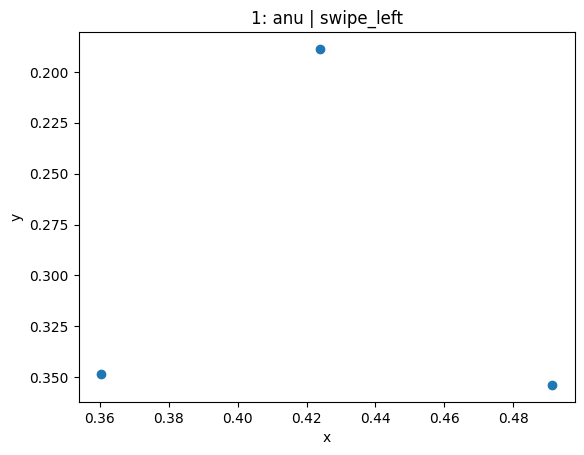

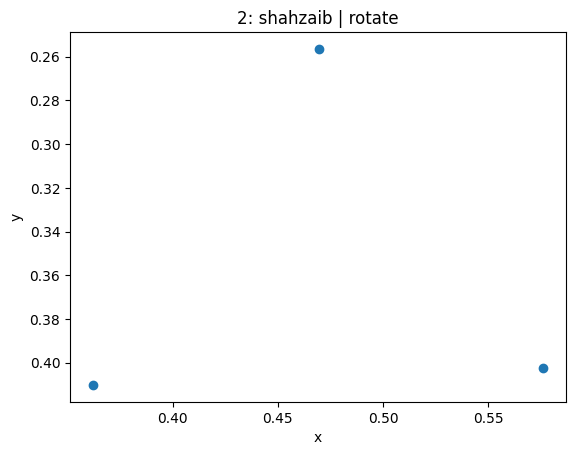

In [29]:
import matplotlib.pyplot as plt

def mean_position_plot(df: pd.DataFrame, title=""):
    cols = [c for c in ["nose_x","nose_y","left_shoulder_x","left_shoulder_y","right_shoulder_x","right_shoulder_y"] if c in df.columns]
    if not cols:
        print("Missing expected columns in dataframe.")
        return
    means = df[cols].mean()
    xs = [means[c] for c in cols if c.endswith("_x")]
    ys = [means[c] for c in cols if c.endswith("_y")]

    plt.figure()
    plt.scatter(xs, ys)
    plt.gca().invert_yaxis()
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()

for i, df in enumerate(list_of_frames):
    mean_position_plot(df, title=f"{i}: {df['person_id'].iloc[0]} | {df['video_label'].iloc[1]}")


#### Top changing features

In [30]:
def top_changing_features(df: pd.DataFrame, k=12):
    num = df.select_dtypes(include=[np.number])
    score = num.diff().abs().mean().sort_values(ascending=False)
    return score.head(k)

for i, df in enumerate(list_of_frames):
    print(f"\nTop-changing features for video {i} ({df['person_id'].iloc[0]} | {df['video_label'].iloc[1]}):")
    display(top_changing_features(df, k=10))



Top-changing features for video 0 (ahad | swipe_right):


left_pinky_z          0.028586
left_index_z          0.027396
left_wrist_z          0.026621
left_thumb_z          0.026382
right_index_z         0.018288
right_foot_index_z    0.018102
right_pinky_z         0.017835
right_heel_z          0.016642
right_thumb_z         0.016463
right_wrist_z         0.016094
dtype: float64


Top-changing features for video 1 (anu | swipe_left):


right_pinky_z         0.020540
right_index_z         0.019573
right_wrist_z         0.019346
right_thumb_z         0.018920
right_foot_index_z    0.016451
left_index_z          0.014835
left_pinky_z          0.014705
right_index_y         0.014668
left_eye_outer_z      0.014509
left_eye_inner_z      0.014507
dtype: float64


Top-changing features for video 2 (shahzaib | rotate):


left_pinky_z     0.035894
left_index_z     0.034733
left_wrist_z     0.032792
left_thumb_z     0.032588
right_index_z    0.029439
right_pinky_z    0.029280
right_thumb_z    0.026522
right_wrist_z    0.026089
left_index_y     0.021727
left_pinky_y     0.021465
dtype: float64

#### Compare Gestures Visually

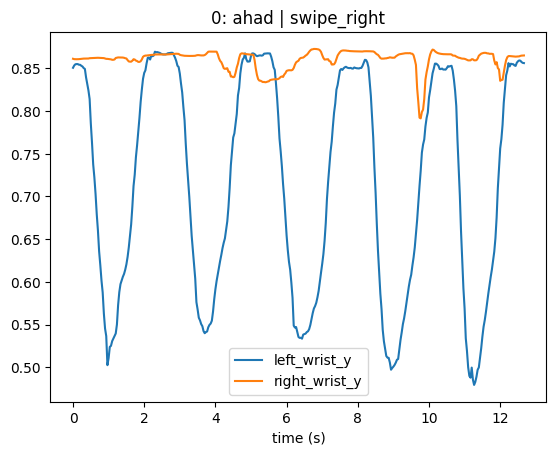

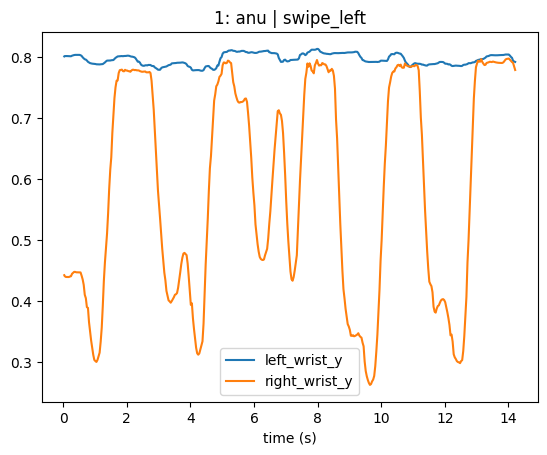

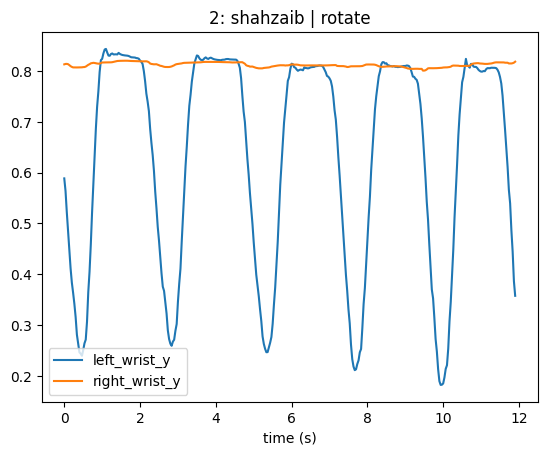

In [31]:
def plot_wrist_signals(df: pd.DataFrame, title=""):
    plt.figure()
    if "left_wrist_y" in df.columns:
        plt.plot(df.index.total_seconds(), df["left_wrist_y"], label="left_wrist_y")
    if "right_wrist_y" in df.columns:
        plt.plot(df.index.total_seconds(), df["right_wrist_y"], label="right_wrist_y")
    plt.title(title)
    plt.xlabel("time (s)")
    plt.legend()
    plt.show()

for i, df in enumerate(list_of_frames):
    plot_wrist_signals(df, title=f"{i}: {df['person_id'].iloc[0]} | {df['video_label'].iloc[1]}")


### E03 — Findings

 **Upper-body dominance:** Wrists, elbows, shoulders drive gesture signals; lower body (feet/ankles) remains static.

**Position variability:** Different people stand at varying x/y locations across videos.

**FPS inconsistency:** Device differences create irregular frame rates.

**Jitter in joints:** Tracking noise affects subtle coordinates.

**Motion > position:** Velocity features capture gesture dynamics better.

### E04 — Resampling frames to fixed FPS

In [32]:
def resample_data(frames: pd.DataFrame, target_fps: int = 30) -> pd.DataFrame:
    # require time index
    if not isinstance(frames.index, pd.TimedeltaIndex):
        raise TypeError("frames.index must be a TimedeltaIndex (convert ms -> timedetla first).")

    step_ms = int(round(1000 / target_fps))
    rule = f"{step_ms}ms"

    numeric = frames.select_dtypes(include=[np.number])
    out = numeric.resample(rule).mean()

    if "ground_truth" in frames.columns:
        out["ground_truth"] = frames["ground_truth"].resample(rule).ffill()

    if "person_id" in frames.columns:
        out["person_id"] = frames["person_id"].iloc[0]
    if "video_label" in frames.columns:
        out["video_label"] = frames["video_label"].iloc[1]

    return out


In [33]:
# Test
df0 = list_of_frames[0]
print("fps before:", estimate_fps(df0))
df0r = resample_data(df0, target_fps=30)
print("fps after:", estimate_fps(df0r))
df0r.head()

fps before: 30.000000300000004
fps after: 30.3030303030303


,nose_x,nose_y,nose_z,nose_confidence,left_eye_inner_x,left_eye_inner_y,left_eye_inner_z,left_eye_inner_confidence,left_eye_x,left_eye_y,...,left_foot_index_y,left_foot_index_z,left_foot_index_confidence,right_foot_index_x,right_foot_index_y,right_foot_index_z,right_foot_index_confidence,ground_truth,person_id,video_label
time,,,,,,,,,,,,,,,,,,,,,
0 days 00:00:00,0.496149,0.309479,-0.396005,0.999986,0.509140,0.286675,-0.368934,0.999958,0.516136,0.287066,...,1.391274,0.317570,0.008352,0.425115,1.386729,0.309909,0.011077,idle,ahad,swipe_right
0 days 00:00:00.033000,0.497481,0.310455,-0.401050,0.999986,0.510050,0.287406,-0.374715,0.999960,0.516615,0.287745,...,1.405927,0.248318,0.009275,0.427405,1.406969,0.209634,0.011726,idle,ahad,swipe_right
0 days 00:00:00.066000,0.498363,0.311305,-0.396325,0.999987,0.510689,0.287893,-0.371066,0.999963,0.517051,0.288198,...,1.411113,0.231388,0.010402,0.427683,1.413090,0.217124,0.012554,swipe_right,ahad,swipe_right
0 days 00:00:00.099000,0.499022,0.311857,-0.396554,0.999987,0.511337,0.288129,-0.371404,0.999965,0.517607,0.288423,...,1.414940,0.220766,0.011101,0.427662,1.415913,0.233450,0.012843,swipe_right,ahad,swipe_right
0 days 00:00:00.132000,0.499038,0.311998,-0.401247,0.999988,0.511467,0.288179,-0.375967,0.999966,0.517713,0.288485,...,1.416216,0.226210,0.011714,0.427668,1.417108,0.227467,0.013211,swipe_right,ahad,swipe_right


In [34]:
# Resample ALL videos
list_of_frames_resampled = [resample_data(df, 30) for df in list_of_frames]

# Check each
for i, df in enumerate(list_of_frames_resampled):
    print(f"Video {i}: {df['video_label'].iloc[0]}")
    print(df["ground_truth"].value_counts())
    print()


Video 0: swipe_right
ground_truth
idle           256
swipe_right    128
Name: count, dtype: int64

Video 1: swipe_left
ground_truth
swipe_left    222
idle          208
Name: count, dtype: int64

Video 2: rotate
ground_truth
rotate    268
idle       93
Name: count, dtype: int64



### E05 — Remove unnecessary features

In [35]:
def delete_features(frames: pd.DataFrame, features: list[str]) -> pd.DataFrame:
    return frames.drop(columns=[f for f in features if f in frames.columns])


In [36]:
foot_ankle_prefixes = ["foot", "ankle", "heel"]
list_of_frames_small = []

for df in list_of_frames:
    to_drop = [c for prefixes in foot_ankle_prefixes 
               for c in df.columns if c.startswith(prefixes)]
    df_small = delete_features(df, to_drop)
    list_of_frames_small.append(df_small)
    print(f"{df['video_label'].iloc[0]}: {len(df.columns)} -> {len(df_small.columns)} cols")


swipe_right: 135 -> 135 cols
swipe_left: 135 -> 135 cols
rotate: 135 -> 135 cols


In [37]:
[len(df.columns) for df in list_of_frames_small]

[135, 135, 135]

### E06 — Five additional preprocessing steps (non-standard)

#### Mask low-confidence coordinates + interpolate

In [38]:
def mask_low_confidence(frames: pd.DataFrame, threshold: float = 0.6) -> pd.DataFrame:
    out = frames.copy()
    conf_cols = [c for c in out.columns if c.endswith("_confidence")]
    for conf in conf_cols:
        base = conf.replace("_confidence", "")
        coords = [f"{base}_{a}" for a in ["x","y","z"] if f"{base}_{a}" in out.columns]
        bad = out[conf] < threshold
        out.loc[bad, coords] = np.nan

    num = out.select_dtypes(include=[np.number])
    out[num.columns] = num.interpolate(method="time").ffill().bfill()
    return out


#### Smooth jitter (rolling median)

In [39]:
def smooth(frames: pd.DataFrame, window: int = 7) -> pd.DataFrame:
    out = frames.copy()
    num_cols = out.select_dtypes(include=[np.number]).columns
    out[num_cols] = out[num_cols].rolling(window=window, center=True, min_periods=1).median()
    return out


#### Re-center around mid-hip (remove camera position effect)

In [40]:
def recenter(frames: pd.DataFrame, left="left_hip", right="right_hip") -> pd.DataFrame:
    out = frames.copy()
    for axis in ["x","y","z"]:
        l, r = f"{left}_{axis}", f"{right}_{axis}"
        if l in out.columns and r in out.columns:
            center = (out[l] + out[r]) / 2.0
            axis_cols = [c for c in out.columns if c.endswith(f"_{axis}") and not c.endswith("_confidence")]
            out[axis_cols] = out[axis_cols].sub(center, axis=0)
    return out


#### Add velocity features for wrists (movement info)

In [41]:
def add_velocity(frames: pd.DataFrame, joints=("left_wrist","right_wrist")) -> pd.DataFrame:
    out = frames.copy()
    t = out.index.to_series().dt.total_seconds()
    dt = t.diff().replace(0, np.nan)

    for j in joints:
        for axis in ["x","y","z"]:
            col = f"{j}_{axis}"
            if col in out.columns:
                out[f"{col}_vel"] = (out[col].diff() / dt).fillna(0)
    return out


#### Trim to “interesting” time windows (reduce idle dominance)

In [42]:
def trim_to_gestures(frames: pd.DataFrame, margin_s: float = 0.5) -> pd.DataFrame:
    if "ground_truth" not in frames.columns:
        return frames

    non_idle = frames["ground_truth"] != "idle"
    if non_idle.sum() == 0:
        return frames

    t0 = frames.index[non_idle].min() - pd.to_timedelta(margin_s, unit="s")
    t1 = frames.index[non_idle].max() + pd.to_timedelta(margin_s, unit="s")
    t0 = max(t0, frames.index.min())
    t1 = min(t1, frames.index.max())
    return frames.loc[(frames.index >= t0) & (frames.index <= t1)]


#### Test Preprocessing

In [43]:
df = list_of_frames[0]
dfp = resample_data(df, 30)
dfp = mask_low_confidence(dfp, 0.6)
dfp = smooth(dfp, 7)
dfp = recenter(dfp)
dfp = add_velocity(dfp)
dfp = trim_to_gestures(dfp, 0.5)

dfp.head()


,nose_x,nose_y,nose_z,nose_confidence,left_eye_inner_x,left_eye_inner_y,left_eye_inner_z,left_eye_inner_confidence,left_eye_x,left_eye_y,...,right_foot_index_confidence,ground_truth,person_id,video_label,left_wrist_x_vel,left_wrist_y_vel,left_wrist_z_vel,right_wrist_x_vel,right_wrist_y_vel,right_wrist_z_vel
time,,,,,,,,,,,,,,,,,,,,,
0 days 00:00:00,0.010291,-0.529713,-0.396761,0.999987,0.022738,-0.552943,-0.371556,0.999961,0.029202,-0.552621,...,0.012140,idle,ahad,swipe_right,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
0 days 00:00:00.033000,0.010647,-0.530833,-0.396879,0.999987,0.022974,-0.554245,-0.371729,0.999963,0.029335,-0.553940,...,0.012554,idle,ahad,swipe_right,-0.002511,-0.025117,-0.065370,0.003515,-0.047675,-0.044774
0 days 00:00:00.066000,0.010995,-0.531374,-0.396774,0.999987,0.023316,-0.554944,-0.371570,0.999964,0.029632,-0.554644,...,0.012699,swipe_right,ahad,swipe_right,0.000615,-0.032712,0.059955,0.011587,-0.023573,-0.010295
0 days 00:00:00.099000,0.011343,-0.531916,-0.396669,0.999987,0.023658,-0.555644,-0.371411,0.999965,0.029928,-0.555349,...,0.012843,swipe_right,ahad,swipe_right,0.000615,-0.032712,0.059955,0.011587,-0.023573,0.009704
0 days 00:00:00.132000,0.011462,-0.532157,-0.396904,0.999988,0.023890,-0.556024,-0.371753,0.999966,0.030136,-0.555698,...,0.013211,swipe_right,ahad,swipe_right,0.003591,-0.011601,-0.000156,0.013618,-0.011601,-0.020156


In [44]:
processed_frames = []
for df in list_of_frames:
    x = resample_data(df, 30)
    x["ground_truth"] = (x["ground_truth"].astype(str)
                         .str.strip().str.lower().str.replace(" ", "_", regex=False))
    x = mask_low_confidence(x, 0.6)
    x = smooth(x, 7)
    x = recenter(x)
    x = add_velocity(x)
    x = trim_to_gestures(x, 0.5)
    processed_frames.append(x)

len(processed_frames), processed_frames[0].shape

(3, (355, 141))